# Chocolate Sales Dataset 2023-2024 - Exploratory Data Analysis (EDA)

**Capstone Project II: ChocoDelight Data Platform**

This notebook performs Exploratory Data Analysis on the Chocolate Sales Dataset before loading it into the PostgreSQL database.

**Objectives:**
- Understand the structure of all 5 tables
- Check data quality (missing values, duplicates)
- Analyze distributions and relationships
- Discover initial business insights
- Prepare findings for the ETL pipeline and schema design

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Define path
import pandas as pd

raw_path = '../data/raw/'

# Load all tables
products = pd.read_csv(raw_path + 'products.csv')
stores = pd.read_csv(raw_path + 'stores.csv')
customers = pd.read_csv(raw_path + 'customers.csv')
calendar = pd.read_csv(raw_path + 'calendar.csv')
sales = pd.read_csv(raw_path + 'sales.csv')

print(f"Products shape: {products.shape}")
print(f"Stores shape: {stores.shape}")
print(f"Customers shape: {customers.shape}")
print(f"Calendar shape: {calendar.shape}")
print(f"Sales shape: {sales.shape}")

Products shape: (200, 6)
Stores shape: (100, 5)
Customers shape: (50000, 5)
Calendar shape: (731, 6)
Sales shape: (1000000, 11)


## 1. Dataset Overview

In [15]:
# Display basic information for each table
print("=== PRODUCTS ===")
print(products.info())
print("\nFirst 5 rows:")
display(products.head())

print("\n=== STORES ===")
print(stores.info())
display(stores.head())

print("\n=== CUSTOMERS ===")
print(customers.info())
display(customers.head())

print("\n=== CALENDAR ===")
print(calendar.info())
display(calendar.head())

print("\n=== SALES ===")
print(sales.info())
display(sales.head())

=== PRODUCTS ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     200 non-null    str  
 1   product_name   200 non-null    str  
 2   brand          200 non-null    str  
 3   category       200 non-null    str  
 4   cocoa_percent  200 non-null    int64
 5   weight_g       200 non-null    int64
dtypes: int64(2), str(4)
memory usage: 9.5 KB
None

First 5 rows:


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50



=== STORES ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    100 non-null    str  
 1   store_name  100 non-null    str  
 2   city        100 non-null    str  
 3   country     100 non-null    str  
 4   store_type  100 non-null    str  
dtypes: str(5)
memory usage: 4.0 KB
None


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online



=== CUSTOMERS ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     50000 non-null  str  
 1   age             50000 non-null  int64
 2   gender          50000 non-null  str  
 3   loyalty_member  50000 non-null  int64
 4   join_date       50000 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.9 MB
None


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31



=== CALENDAR ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         731 non-null    str  
 1   year         731 non-null    int64
 2   month        731 non-null    int64
 3   day          731 non-null    int64
 4   week         731 non-null    int64
 5   day_of_week  731 non-null    int64
dtypes: int64(5), str(1)
memory usage: 34.4 KB
None


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3



=== SALES ===
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  str    
 1   order_date   1000000 non-null  str    
 2   product_id   1000000 non-null  str    
 3   store_id     1000000 non-null  str    
 4   customer_id  1000000 non-null  str    
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), str(5)
memory usage: 83.9 MB
None


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [16]:
# Missing values summary
print("Missing Values Analysis:\n")

for name, df in [("Products", products), ("Stores", stores), ("Customers", customers),
                 ("Calendar", calendar), ("Sales", sales)]:
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"{name}: {missing[missing > 0]}")
    else:
        print(f"{name}: No missing values")

Missing Values Analysis:

Products: No missing values
Stores: No missing values
Customers: No missing values
Calendar: No missing values
Sales: No missing values


In [17]:
print("=== SALES - Descriptive Statistics ===")
display(sales.describe())

print("\n=== PRODUCTS - Descriptive Statistics ===")
display(products.describe())

=== SALES - Descriptive Statistics ===


,quantity,unit_price,discount,revenue,cost,profit
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000



=== PRODUCTS - Descriptive Statistics ===


,cocoa_percent,weight_g
count,200.000000,200.000000
mean,69.150000,107.500000
std,14.623499,50.898954
min,50.000000,50.000000
25%,50.000000,80.000000
50%,70.000000,100.000000
75%,80.000000,120.000000
max,90.000000,200.000000


## 2. Key Business Insights

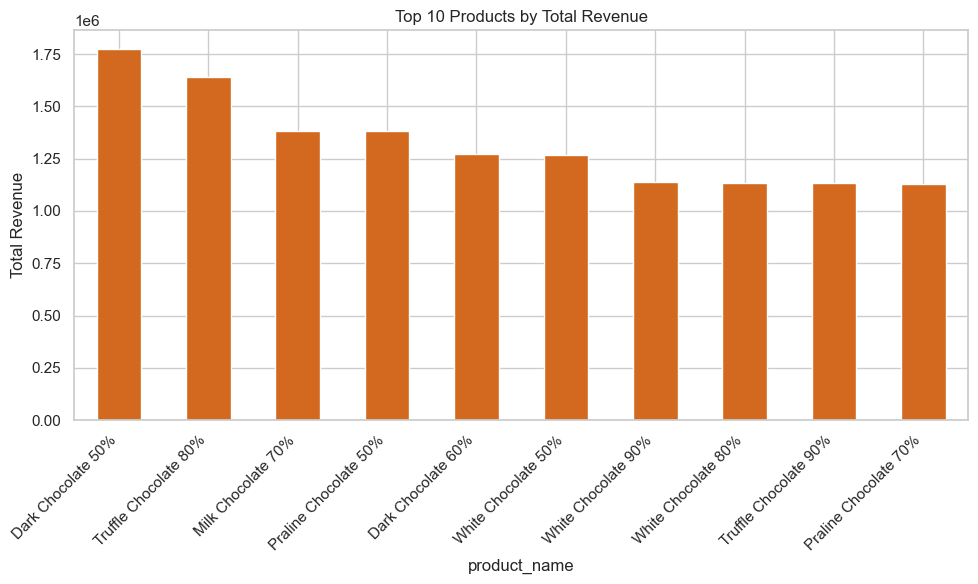

product_name
Dark Chocolate 50%       1775041.34
Truffle Chocolate 80%    1643258.83
Milk Chocolate 70%       1384758.27
Praline Chocolate 50%    1382597.04
Dark Chocolate 60%       1272649.97
White Chocolate 50%      1265949.75
White Chocolate 90%      1137968.57
White Chocolate 80%      1133285.39
Truffle Chocolate 90%    1132883.80
Praline Chocolate 70%    1127404.94
Name: revenue, dtype: float64


In [18]:
# Top 10 Products by Revenue
top_products = sales.merge(products, on='product_id') \
                    .groupby('product_name')['revenue'].sum() \
                    .sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='chocolate')
plt.title('Top 10 Products by Total Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_products)

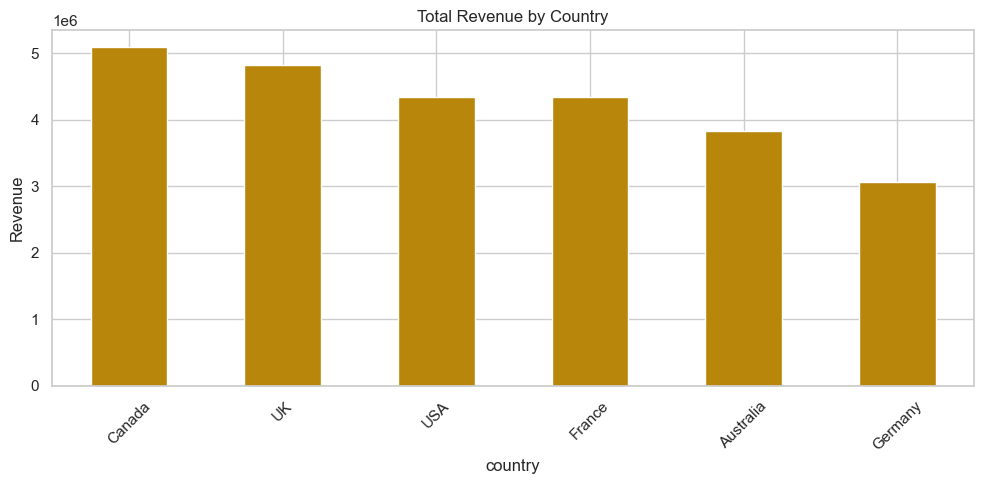

In [19]:
# Sales by Country
country_revenue = sales.merge(stores, on='store_id') \
                       .groupby('country')['revenue'].sum() \
                       .sort_values(ascending=False)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind='bar', color='darkgoldenrod')
plt.title('Total Revenue by Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

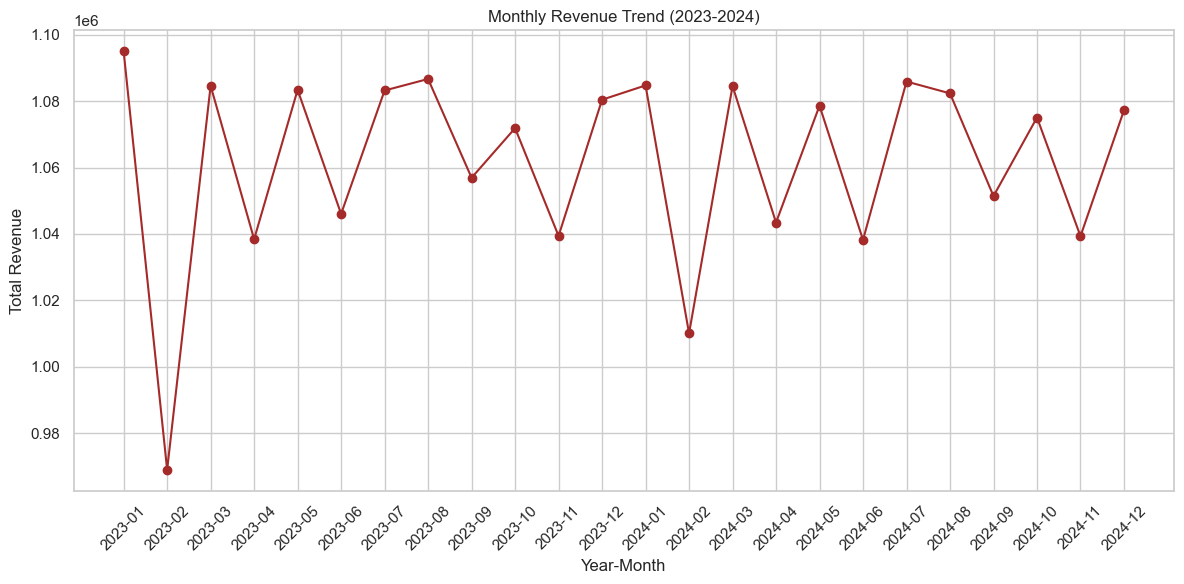

In [20]:
# Monthly Revenue Trend
monthly_sales = sales.merge(calendar, left_on='order_date', right_on='date') \
                     .groupby(['year', 'month'])['revenue'].sum().reset_index()

monthly_sales['year_month'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['year_month'], monthly_sales['revenue'], marker='o', color='brown')
plt.title('Monthly Revenue Trend (2023-2024)')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion & Key Findings

1. The dataset follows a clean **Star Schema** design (4 dimensions + 1 fact table).
2. No major missing values were found in core tables.
3. Revenue is heavily influenced by a few top-performing chocolate products.
4. Significant seasonal patterns exist (especially in Q4 and Summer months).
5. Country-level performance varies notably.

**Next Steps:**
- Proceed with automated ETL pipeline
- Implement 2NF normalization and constraints
- Build analytical views and segmentation logic